# September Sea Ice Area — Time of Emergence
## G6-1.5K-SAI and G6-1.5K-HiLLA vs SSP2-4.5 | All four models

**Method:** Cumulative one-sided Welch's t-test applied to each paired member, testing whether
September NH sea ice area under the geoengineering scenario *exceeds* that of its paired SSP2-4.5
member (i.e. sea ice recovery relative to the counterfactual), p < 0.05. **Member ToE** = first
year Y ≥ 2035 at which the cumulative window [2035, Y] is significant. **Model ToE ("p66")** =
k-th earliest member ToE, k = ⌈0.66 × N⌉.

| Model | Members | SAI sea ice |
|---|---|---|
| MIROC-ES2H | 10 | yes |
| CESM2-WACCM | 3 | yes |
| UKESM1-1 | 3 | no |
| E3SMv3 | 3 | no |

CESM2-WACCM SSP2-4.5 uses the first 3 members of the public ARISE ensemble (r001–r003), paired 1:1
with HiLLA/SAI r1–r3. MIROC-ES2H bootstrap: all C(10,3) = 120 three-member subsets.

In [5]:
import sys
import fsspec
import xarray as xr
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker
from scipy import stats
from itertools import combinations
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle

matplotlib.rcParams.update({'font.size': 15})

sys.path.append('../shared/Code_examples/G6-1.5K_example/')
from Utils import set_time_to_center_of_bounds

SAI_START  = 2035
ALPHA      = 0.05
MIN_N      = 2
PLOT_START = 2020
PLOT_END   = 2084

## 1. File paths

In [6]:
# ── CESM2-WACCM ───────────────────────────────────────────────────────────────
# SSP2-4.5: ARISE public bucket (anon=True); members 001-005 run to 2100, 006-010 to 2069.
# We load only the first 3 members for pairing with HiLLA/SAI r1-r3.
ssp245_base   = 'ncar-cesm2-arise/CESM2-WACCM-SSP245/'
_ssp245_ends  = {m: '210012' if int(m) <= 5 else '206912'
                 for m in [f'{i:03d}' for i in range(1, 11)]}
cesm_ssp245_ice_files = [
    [f's3://{ssp245_base}b.e21.BWSSP245cmip6.f09_g17.CMIP6-SSP2-4.5-WACCM.{m}/atm/proc/tseries/month_1/'
     f'b.e21.BWSSP245cmip6.f09_g17.CMIP6-SSP2-4.5-WACCM.{m}.cam.h0.ICEFRAC.201501-206412.nc',
     f's3://{ssp245_base}b.e21.BWSSP245cmip6.f09_g17.CMIP6-SSP2-4.5-WACCM.{m}/atm/proc/tseries/month_1/'
     f'b.e21.BWSSP245cmip6.f09_g17.CMIP6-SSP2-4.5-WACCM.{m}.cam.h0.ICEFRAC.206501-{_ssp245_ends[m]}.nc']
    for m in list(_ssp245_ends)[:3]   # paired members only
]
cesm_HiLLA_ice_files = [
    ['s3://reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-HiLLA/r1/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.001.cam.h0.ICEFRAC.203501-203912.nc',
     's3://reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-HiLLA/r1/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.001.cam.h0.ICEFRAC.204001-208412.nc'],
    ['s3://reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-HiLLA/r2/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.002.cam.h0.ICEFRAC.203501-208412.nc'],
    ['s3://reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-HiLLA/r3/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-HiLLA.003.cam.h0.ICEFRAC.203501-208412.nc'],
]
cesm_SAI_ice_files = [
    ['s3://reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-SAI/r1/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-SAI.001.cam.h0.ICEFRAC.203501-208412.nc'],
    ['s3://reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-SAI/r2/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-SAI.002.cam.h0.ICEFRAC.203501-208412.nc'],
    ['s3://reflective-persistent-prod-large/CESM2-WACCM/G6-1.5k-SAI/r3/AMON/b.e21.BW.f09_g17.SSP245-G6-1p5K-SAI.003.cam.h0.ICEFRAC.203501-208412.nc'],
]

# ── UKESM1-1 — SAI sea ice data not available ─────────────────────────────────
ukesm_HiLLA_ice_paths = [
    's3://reflective-persistent-prod-large/UKESM1-1/G6-1p5K-HiLLA/r12i1p1f2/apm/SImon/siconca/',
    's3://reflective-persistent-prod-large/UKESM1-1/G6-1p5K-HiLLA/r2i1p1f2/apm/SImon/siconca/',
    's3://reflective-persistent-prod-large/UKESM1-1/G6-1p5K-HiLLA/r3i1p1f2/apm/SImon/siconca/',
]
ukesm_ssp245_ice_paths = [
    's3://reflective-persistent-prod-large/UKESM1-1/SSP245/r12i1p1f1/ap5/SImon/siconca/',
    's3://reflective-persistent-prod-large/UKESM1-1/SSP245/r2i1p1f1/ap5/SImon/siconca/',
    's3://reflective-persistent-prod-large/UKESM1-1/SSP245/r3i1p1f1/ap5/SImon/siconca/',
]

# ── MIROC-ES2H — all 10 members ───────────────────────────────────────────────
# SAI files use variable name 'SeaIce'; read_miroc_ice handles this.
miroc_HiLLA_ice_files  = [f's3://reflective-persistent-prod-large/MIROC-ES2H/G6-1.5K-HiLLA/Omon/siconc_G6-1.5K-HiLLA_r{i:02d}.nc' for i in range(1, 11)]
miroc_SAI_ice_files    = [f's3://reflective-persistent-prod-large/MIROC-ES2H/G6-1.5K-SAI/Mon/SeaIce_G6-1.5K-SAI_r{i:02d}.nc'    for i in range(1, 11)]
miroc_ssp245_ice_files = [f's3://reflective-persistent-prod-large/MIROC-ES2H/G6-1.5K-HiLLA/Omon/siconc_baseline_r{i:02d}.nc'     for i in range(1, 11)]

# ── E3SMv3 — SAI sea ice not available; HiLLA/SSP245 already regridded ────────
_E3SM_DEST = 'reflective-persistent-prod'
e3sm_HiLLA_ice_files  = [[f's3://{_E3SM_DEST}/alistairduffey/E3SMv3/G6-1.5K-HiLLA/{r}/ICEFRAC/ICEFRAC_combined.nc'] for r in ['r1', 'r2', 'r3']]
e3sm_ssp245_ice_files = [[f's3://{_E3SM_DEST}/alistairduffey/E3SMv3/SSP245/{r}/ICEFRAC/ICEFRAC_combined.nc']         for r in ['r1', 'r2', 'r3']]

print('File paths defined.')

File paths defined.


## 2. Reader functions and SIA computation

In [7]:
def read_ice_from_file_list(file_list_of_lists, rename_var=None, scale=1.0, open_kwargs=None):
    """Read sea ice data for multiple members, each given as a list of file paths."""
    if open_kwargs is None:
        open_kwargs = {}
    ds_list = []
    for member_files in file_list_of_lists:
        file_objects = [fsspec.open(f, mode='rb', **open_kwargs) for f in member_files]
        ds = xr.open_mfdataset([f.open() for f in file_objects],
                               combine='nested', concat_dim='time', chunks={}).load()
        _, idx = np.unique(ds.time, return_index=True)
        ds = ds.isel(time=idx)
        if rename_var and rename_var in ds:
            ds = ds.rename({rename_var: 'siconc'})
        if scale != 1.0:
            ds['siconc'] = ds['siconc'] * scale
        ds_list.append(ds)
    return ds_list


def read_ice_from_directory_paths(path_list, rename_var=None, scale=1.0, time_slice=None):
    """Read sea ice data where each member lives in a directory of .nc files (UKESM)."""
    ds_list = []
    for path in path_list:
        files = fsspec.open_files(f'{path}*.nc', mode='rb')
        ds = xr.open_mfdataset([f.open() for f in files],
                               combine='nested', concat_dim='time', chunks={}).load()
        _, idx = np.unique(ds.time, return_index=True)
        ds = ds.isel(time=idx)
        if rename_var and rename_var in ds:
            ds = ds.rename({rename_var: 'siconc'})
        if scale != 1.0:
            ds['siconc'] = ds['siconc'] * scale
        if time_slice:
            ds = ds.sel(time=slice(*time_slice))
        ds_list.append(ds)
    return ds_list


def read_miroc_ice(file_list):
    """MIROC-ES2H: rename non-standard lat dim, convert fraction 0-1 to %.

    The files contain auxiliary dims (e.g. bnds=2 for time_bnds) in addition to the
    true spatial lat dim (OCLATTPT256 = 256 points). We filter by size > 10 to avoid
    accidentally renaming the bounds dim to 'lat', which would conflict with siconc.
    """
    ds_list = []
    for f in file_list:
        with fsspec.open(f, mode='rb') as fobj:
            ds = xr.open_dataset(fobj, engine='h5netcdf', chunks={}).load()
        lat_dim = [d for d in ds.dims
                   if d not in ('lon', 'time') and ds.dims[d] > 10]
        if lat_dim and lat_dim[0] != 'lat':
            ds = ds.rename({lat_dim[0]: 'lat'})
        for var in list(ds.data_vars):
            if any(k in var.lower() for k in ('ice', 'conc', 'seaice')):
                if var != 'siconc':
                    ds = ds.rename({var: 'siconc'})
                ds['siconc'] = ds['siconc'] * 100.0
                break
        ds_list.append(ds)
    return ds_list


# ── SIA functions (from seaice_ToE_main) ─────────────────────────────────────
R_EARTH = 6.371e6

def compute_cell_area(lat, lon):
    """2D DataArray of grid cell areas (m²) for a regular lat/lon grid."""
    dlat = np.deg2rad(np.abs(float(lat[1] - lat[0])))
    dlon = np.deg2rad(np.abs(float(lon[1] - lon[0])))
    cos_lat = np.cos(np.deg2rad(lat))
    area = R_EARTH**2 * cos_lat * dlat * dlon
    return area.expand_dims({'lon': len(lon)}, axis=1)


def _trim_partial_years(da):
    """Drop any year at the start/end that is not a complete 12-month year."""
    if da.time.dt.month.values[0] != 1:
        da = da.sel(time=da.time.dt.year >= int(da.time.dt.year.values[0]) + 1)
    if da.time.dt.month.values[-1] != 12:
        da = da.sel(time=da.time.dt.year <= int(da.time.dt.year.values[-1]) - 1)
    return da


def sia_timeseries(ds_list, month=9, lat_name='lat', lon_name='lon', lat_min=0.0):
    """NH sea ice area (10^6 km^2) for a given month, one DataArray per member.
    DataArray is indexed by integer year.
    """
    out = []
    for ds in ds_list:
        da = ds['siconc']
        if 'latitude' in da.dims:
            da = da.rename({'latitude': 'lat', 'longitude': 'lon'})
        da_nh = da.sel(**{lat_name: slice(lat_min, 90)})
        area  = compute_cell_area(da_nh[lat_name], da_nh[lon_name])
        sia   = ((da_nh / 100.0) * area).sum([lat_name, lon_name]) / 1e12
        sia   = _trim_partial_years(sia)
        ts    = sia.sel(time=sia.time.dt.month == month)
        ts    = ts.assign_coords(time=ts.time.dt.year)
        out.append(ts)
    return out


print('Reader functions defined.')


Reader functions defined.


## 3. Load data

In [8]:
print('Loading CESM2-WACCM...')
cesm_HiLLA_ice  = read_ice_from_file_list(cesm_HiLLA_ice_files, rename_var='ICEFRAC', scale=100.0)
cesm_SAI_ice    = read_ice_from_file_list(cesm_SAI_ice_files,   rename_var='ICEFRAC', scale=100.0)
cesm_ssp245_ice = read_ice_from_file_list(cesm_ssp245_ice_files, rename_var='ICEFRAC', scale=100.0,
                                          open_kwargs={'anon': True})
cesm_HiLLA_ice  = [set_time_to_center_of_bounds(ds, time_bounds_name='time_bnds') for ds in cesm_HiLLA_ice]
cesm_SAI_ice    = [set_time_to_center_of_bounds(ds, time_bounds_name='time_bnds') for ds in cesm_SAI_ice]
cesm_ssp245_ice = [set_time_to_center_of_bounds(ds, time_bounds_name='time_bnds') for ds in cesm_ssp245_ice]
print(f'  HiLLA {len(cesm_HiLLA_ice)}, SAI {len(cesm_SAI_ice)}, SSP245 {len(cesm_ssp245_ice)} members')

print('Loading UKESM1-1...')
ukesm_HiLLA_ice  = read_ice_from_directory_paths(ukesm_HiLLA_ice_paths,  rename_var='siconca',
                                                  time_slice=('2035', '2084'))
ukesm_ssp245_ice = read_ice_from_directory_paths(ukesm_ssp245_ice_paths, rename_var='siconca')
print(f'  HiLLA {len(ukesm_HiLLA_ice)}, SSP245 {len(ukesm_ssp245_ice)} members (no SAI available)')

print('Loading MIROC-ES2H...')
miroc_HiLLA_ice  = read_miroc_ice(miroc_HiLLA_ice_files)
miroc_SAI_ice    = read_miroc_ice(miroc_SAI_ice_files)
miroc_ssp245_ice = read_miroc_ice(miroc_ssp245_ice_files)
print(f'  HiLLA {len(miroc_HiLLA_ice)}, SAI {len(miroc_SAI_ice)}, SSP245 {len(miroc_ssp245_ice)} members')

print('Loading E3SMv3...')
e3sm_HiLLA_ice  = read_ice_from_file_list(e3sm_HiLLA_ice_files,  rename_var='ICEFRAC', scale=100.0)
e3sm_ssp245_ice = read_ice_from_file_list(e3sm_ssp245_ice_files, rename_var='ICEFRAC', scale=100.0)
e3sm_HiLLA_ice  = [set_time_to_center_of_bounds(ds, time_bounds_name='time_bnds') for ds in e3sm_HiLLA_ice]
e3sm_ssp245_ice = [set_time_to_center_of_bounds(ds, time_bounds_name='time_bnds') for ds in e3sm_ssp245_ice]
print(f'  HiLLA {len(e3sm_HiLLA_ice)}, SSP245 {len(e3sm_ssp245_ice)} members (no SAI available)')

Loading CESM2-WACCM...


/tmp/ipykernel_143/123153339.py:8: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset([f.open() for f in file_objects],
/tmp/ipykernel_143/123153339.py:8: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset([f.open() for f in file_objects],
/tmp/ipykernel_143/123153339.py:8: F

  HiLLA 3, SAI 3, SSP245 3 members
Loading UKESM1-1...


/tmp/ipykernel_143/123153339.py:25: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset([f.open() for f in files],
/tmp/ipykernel_143/123153339.py:25: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds = xr.open_mfdataset([f.open() for f in files],
/tmp/ipykernel_143/123153339.py:25: FutureWarnin

  HiLLA 3, SSP245 3 members (no SAI available)
Loading MIROC-ES2H...


/tmp/ipykernel_143/123153339.py:51: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  if d not in ('lon', 'time') and ds.dims[d] > 10]
/tmp/ipykernel_143/123153339.py:51: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  if d not in ('lon', 'time') and ds.dims[d] > 10]
/tmp/ipykernel_143/123153339.py:51: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  if d not in ('lon', 'time') and ds.dims[d] > 10]
/

  HiLLA 10, SAI 10, SSP245 10 members
Loading E3SMv3...
  HiLLA 3, SSP245 3 members (no SAI available)


## 4. September sea ice area

In [9]:
print('Computing September SIA...')
sep_sia = {
    'CESM2-WACCM': {
        'SSP2-4.5':       sia_timeseries(cesm_ssp245_ice),
        'G6-1.5K-HiLLA':  sia_timeseries(cesm_HiLLA_ice),
        'G6-1.5K-SAI':    sia_timeseries(cesm_SAI_ice),
    },
    'UKESM1-1': {
        'SSP2-4.5':       sia_timeseries(ukesm_ssp245_ice),
        'G6-1.5K-HiLLA':  sia_timeseries(ukesm_HiLLA_ice),
    },
    'MIROC-ES2H': {
        'SSP2-4.5':       sia_timeseries(miroc_ssp245_ice),
        'G6-1.5K-HiLLA':  sia_timeseries(miroc_HiLLA_ice),
        'G6-1.5K-SAI':    sia_timeseries(miroc_SAI_ice),
    },
    'E3SMv3': {
        'SSP2-4.5':       sia_timeseries(e3sm_ssp245_ice),
        'G6-1.5K-HiLLA':  sia_timeseries(e3sm_HiLLA_ice),
    },
}

for m, d in sep_sia.items():
    for scen, ts_list in d.items():
        yrs = ts_list[0].time.values
        print(f'  {m:<14} {scen:<20} {len(ts_list)} members  {yrs[0]}–{yrs[-1]}')

Computing September SIA...
  CESM2-WACCM    SSP2-4.5             3 members  2015–2100
  CESM2-WACCM    G6-1.5K-HiLLA        3 members  2035–2084
  CESM2-WACCM    G6-1.5K-SAI          3 members  2035–2084
  UKESM1-1       SSP2-4.5             3 members  2015–2100
  UKESM1-1       G6-1.5K-HiLLA        3 members  2035–2084
  MIROC-ES2H     SSP2-4.5             10 members  2020–2084
  MIROC-ES2H     G6-1.5K-HiLLA        10 members  2035–2084
  MIROC-ES2H     G6-1.5K-SAI          10 members  2035–2084
  E3SMv3         SSP2-4.5             3 members  2015–2084
  E3SMv3         G6-1.5K-HiLLA        3 members  2035–2084


## 5. Time of Emergence — cumulative paired t-test

In [10]:
def cumulative_ttest_toe(scen_ts, ssp_ts, start_year=SAI_START, alpha=ALPHA, min_n=MIN_N):
    """Cumulative one-sided Welch's t-test: scen > ssp245 (sea ice recovery).
    scen_ts, ssp_ts: xarray DataArrays indexed by integer year.
    Returns first year Y >= start_year at which p < alpha, or None.
    """
    g_yrs, g_vals = scen_ts.time.values, scen_ts.values
    s_yrs, s_vals = ssp_ts.time.values,  ssp_ts.values
    g_yrs, g_vals = g_yrs[g_yrs >= start_year], g_vals[g_yrs >= start_year]
    s_yrs, s_vals = s_yrs[s_yrs >= start_year], s_vals[s_yrs >= start_year]
    end_year = int(min(g_yrs.max(), s_yrs.max()))
    for Y in range(start_year, end_year + 1):
        g_win, s_win = g_vals[g_yrs <= Y], s_vals[s_yrs <= Y]
        if min(len(g_win), len(s_win)) < min_n:
            continue
        _, p = stats.ttest_ind(g_win, s_win, equal_var=False, alternative='greater')
        if p < alpha:
            return Y
    return None


def count_based_p66(member_toes):
    """k-th earliest member ToE, k = ceil(0.66 * N)."""
    valid = sorted(t for t in member_toes if t is not None)
    k = int(np.ceil(0.66 * len(member_toes)))
    return valid[k - 1] if len(valid) >= k else None


MODELS = ['CESM2-WACCM', 'UKESM1-1', 'MIROC-ES2H', 'E3SMv3']
SCENARIOS_BY_MODEL = {
    'CESM2-WACCM': ['G6-1.5K-HiLLA', 'G6-1.5K-SAI'],
    'UKESM1-1':    ['G6-1.5K-HiLLA'],
    'MIROC-ES2H':  ['G6-1.5K-HiLLA', 'G6-1.5K-SAI'],
    'E3SMv3':      ['G6-1.5K-HiLLA'],
}

member_toes = {m: {} for m in MODELS}
for m in MODELS:
    ssp_list = sep_sia[m]['SSP2-4.5']
    for scen in SCENARIOS_BY_MODEL[m]:
        scen_list = sep_sia[m][scen]
        n = min(len(scen_list), len(ssp_list))
        member_toes[m][scen] = [
            cumulative_ttest_toe(scen_list[i], ssp_list[i]) for i in range(n)
        ]

print(f'{"Model":<14}{"Scenario":<20}{"Member ToEs":<50}{"p66 ToE":>8}')
print('-' * 92)
for m in MODELS:
    for scen in SCENARIOS_BY_MODEL[m]:
        toes = member_toes[m][scen]
        print(f'{m:<14}{scen:<20}{str(toes):<50}{str(count_based_p66(toes)):>8}')

# ── MIROC-ES2H bootstrap: all C(10,3) subsets ─────────────────────────────────
miroc_boot = {}
for scen in ['G6-1.5K-HiLLA', 'G6-1.5K-SAI']:
    toes10 = member_toes['MIROC-ES2H'][scen]
    boot   = [count_based_p66([toes10[i] for i in combo])
              for combo in combinations(range(10), 3)]
    miroc_boot[scen] = [b for b in boot if b is not None]
    p5, p25, p75, p95 = np.percentile(miroc_boot[scen], [5, 25, 75, 95])
    print(f'MIROC {scen}: 5/25/75/95th pct = {p5:.0f}/{p25:.0f}/{p75:.0f}/{p95:.0f}')

Model         Scenario            Member ToEs                                        p66 ToE
--------------------------------------------------------------------------------------------
CESM2-WACCM   G6-1.5K-HiLLA       [2040, 2046, 2037]                                    2040
CESM2-WACCM   G6-1.5K-SAI         [2041, 2050, 2043]                                    2043
UKESM1-1      G6-1.5K-HiLLA       [2041, 2044, 2039]                                    2041
MIROC-ES2H    G6-1.5K-HiLLA       [2043, 2044, 2043, 2038, 2037, 2037, 2037, 2042, 2039, 2045]    2043
MIROC-ES2H    G6-1.5K-SAI         [2037, 2047, 2042, 2043, 2039, 2040, 2037, 2045, 2046, 2037]    2043
E3SMv3        G6-1.5K-HiLLA       [2050, 2049, 2044]                                    2049
MIROC G6-1.5K-HiLLA: 5/25/75/95th pct = 2037/2038/2043/2044
MIROC G6-1.5K-SAI: 5/25/75/95th pct = 2037/2039/2043/2046


## 6. Figure

/tmp/ipykernel_143/1383223985.py:141: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


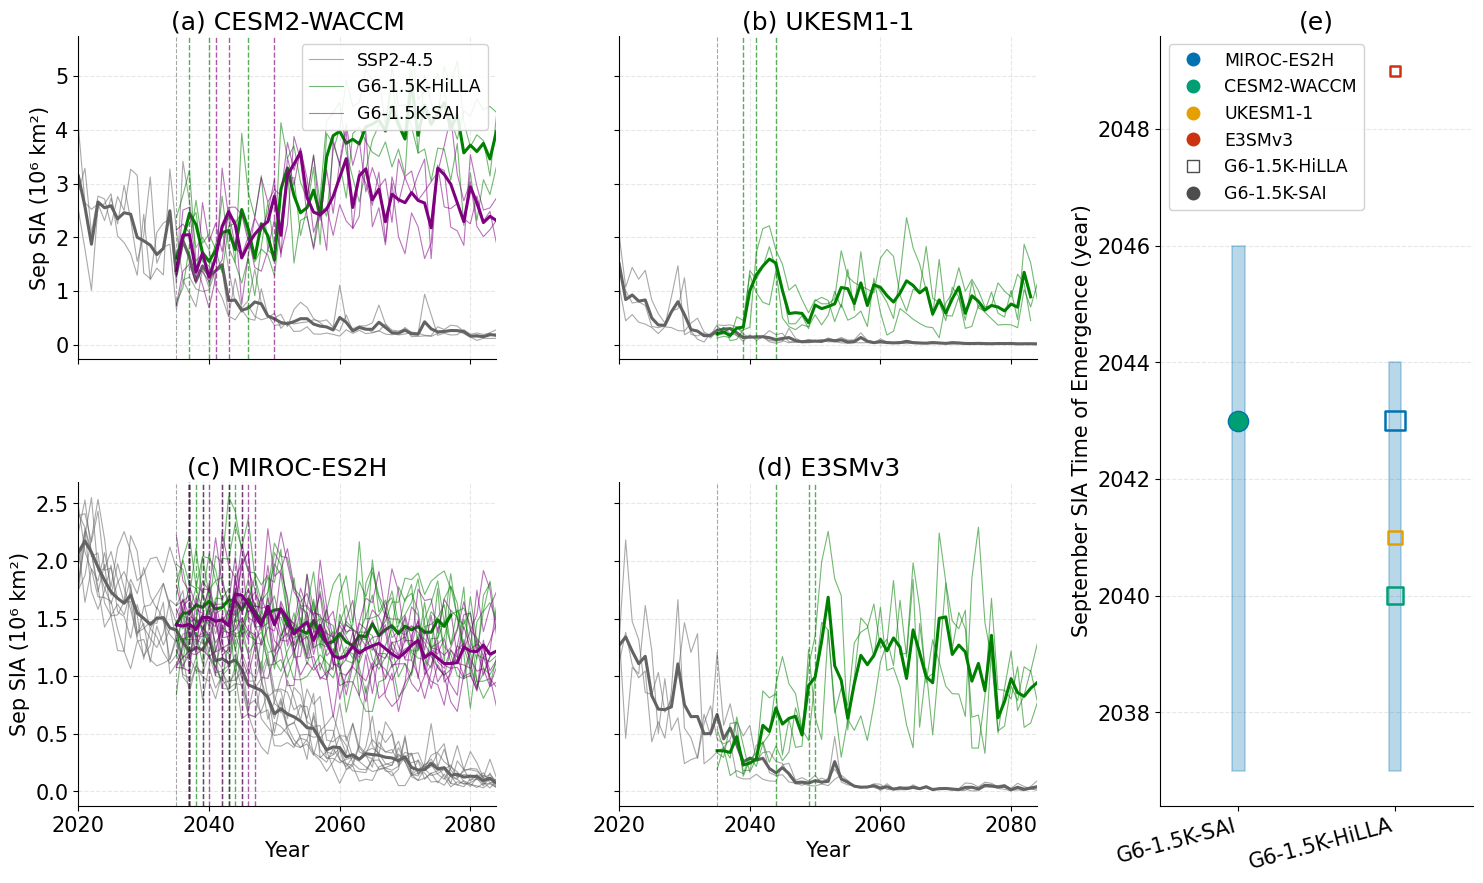

In [15]:
matplotlib.rcParams['font.size'] = 15

# ── Colours ───────────────────────────────────────────────────────────────────
GRAY        = '#636363'
GRAY_LIGHT  = '#D9D9D9'
HILLA_COL   = 'green'
HILLA_LIGHT = 'lightgreen'
SAI_COL     = 'purple'
SAI_LIGHT   = 'plum'

MODEL_COLORS = {
    'MIROC-ES2H':  '#0072B2',
    'CESM2-WACCM': '#009E73',
    'UKESM1-1':    '#E69F00',
    'E3SMv3':      '#CC3311',
}
MODEL_ORDER = ['MIROC-ES2H', 'CESM2-WACCM', 'UKESM1-1', 'E3SMv3']
MODEL_SIZE  = {'MIROC-ES2H': 190, 'CESM2-WACCM': 140, 'UKESM1-1': 95, 'E3SMv3': 55}
SCEN_MARKER = {'G6-1.5K-HiLLA': 's', 'G6-1.5K-SAI': 'o'}
SCEN_ORDER  = ['G6-1.5K-SAI', 'G6-1.5K-HiLLA']

SCEN_STYLE = [
    ('SSP2-4.5',       GRAY,      None),
    ('G6-1.5K-HiLLA',  HILLA_COL, None),
    ('G6-1.5K-SAI',    SAI_COL,   None),
]
MODEL_TS_ORDER = ['CESM2-WACCM', 'UKESM1-1', 'MIROC-ES2H', 'E3SMv3']

# ── Layout ────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig,
                        width_ratios=[1, 1, 0.75],
                        wspace=0.32, hspace=0.38)

ax_a = fig.add_subplot(gs[0, 0])
ax_b = fig.add_subplot(gs[0, 1], sharey=ax_a)
ax_c = fig.add_subplot(gs[1, 0], sharex=ax_a)
ax_d = fig.add_subplot(gs[1, 1], sharex=ax_b, sharey=ax_c)
ax_e = fig.add_subplot(gs[:, 2])

ax_ts     = [ax_a, ax_b, ax_c, ax_d]
ts_labels = ['(a)', '(b)', '(c)', '(d)']

# ── Timeseries panels ─────────────────────────────────────────────────────────
for ax, model, label in zip(ax_ts, MODEL_TS_ORDER, ts_labels):
    for scen, col, _ in SCEN_STYLE:
        if scen not in sep_sia[model]:
            continue
        ts_list = sep_sia[model][scen]
        toes_this = member_toes.get(model, {}).get(scen, [])

        for i, ts in enumerate(ts_list):
            yrs  = ts.time.values
            mask = (yrs >= PLOT_START) & (yrs <= PLOT_END)
            is_first = (i == 0)
            ax.plot(yrs[mask], ts.values[mask],
                    color=col, lw=0.8, alpha=0.55,
                    label=scen if is_first else '_')

            # individual member ToE vlines for geoengineering scenarios
            if scen != 'SSP2-4.5' and i < len(toes_this) and toes_this[i] is not None:
                ax.axvline(toes_this[i], color=col, lw=1.0, ls='--', alpha=0.65)

        # bold ensemble mean
        all_yrs = ts_list[0].time.values
        mask_m  = (all_yrs >= PLOT_START) & (all_yrs <= PLOT_END)
        try:
            stacked = xr.concat(ts_list, dim='member', join='inner')
            yrs_c   = stacked.time.values
            mask_c  = (yrs_c >= PLOT_START) & (yrs_c <= PLOT_END)
            ax.plot(yrs_c[mask_c], stacked.values[:, mask_c].mean(axis=0),
                    color=col, lw=2.2)
        except Exception:
            pass

    ax.axvline(SAI_START, color='k', lw=0.8, ls='--', alpha=0.35)
    ax.set_title(f'{label} {model}', fontsize='large', pad=5)
    ax.set_xlim(PLOT_START, PLOT_END)
    ax.grid(ls='--', alpha=0.3)
    for sp in ('top', 'right'):
        ax.spines[sp].set_visible(False)

# y-labels and x-labels
ax_a.set_ylabel('Sep SIA (10\u2076 km\u00b2)', fontsize='medium')
ax_c.set_ylabel('Sep SIA (10\u2076 km\u00b2)', fontsize='medium')
ax_b.tick_params(labelleft=False)
ax_d.tick_params(labelleft=False)
ax_a.tick_params(labelbottom=False)
ax_b.tick_params(labelbottom=False)
ax_c.set_xlabel('Year', fontsize='medium')
ax_d.set_xlabel('Year', fontsize='medium')

# scenario legend in (a)
ax_a.legend(fontsize='small', loc='upper right', framealpha=0.88)

# ── Panel (e): ToE scatter ─────────────────────────────────────────────────────
for xi, scen in enumerate(SCEN_ORDER):
    for m in MODEL_ORDER:
        if scen not in SCENARIOS_BY_MODEL[m]:
            continue
        col = MODEL_COLORS[m]
        if m == 'MIROC-ES2H':
            boot = miroc_boot[scen]
            p5, p95 = np.percentile(boot, [5, 95])
            bw = 0.08
            ax_e.add_patch(Rectangle(
                (xi - bw / 2, p5), bw, p95 - p5,
                facecolor=col, alpha=0.28, edgecolor=col, linewidth=1.2, zorder=2
            ))
        p66 = count_based_p66(member_toes[m][scen])
        if p66 is not None:
            face = 'none' if scen == 'G6-1.5K-HiLLA' else col
            ax_e.scatter([xi], [p66], marker=SCEN_MARKER[scen],
                         s=MODEL_SIZE[m], facecolors=face,
                         edgecolors=col, linewidths=1.8, zorder=4)

ax_e.set_xticks([0, 1])
ax_e.set_xticklabels(SCEN_ORDER, rotation=15, ha='right', fontsize='medium')
ax_e.set_xlim(-0.5, 1.5)
ax_e.set_ylabel('September SIA Time of Emergence (year)', fontsize='medium')
ax_e.set_title('(e)', fontsize='large', pad=5)
ax_e.yaxis.set_major_locator(matplotlib.ticker.MaxNLocator(integer=True))
ax_e.grid(ls='--', alpha=0.3, axis='y')
for sp in ('top', 'right'):
    ax_e.spines[sp].set_visible(False)

# combined legend for (e)
model_handles = [
    Line2D([0], [0], marker='o', color=MODEL_COLORS[m], lw=0,
           markerfacecolor=MODEL_COLORS[m], markersize=9, label=m)
    for m in MODEL_ORDER
]
scen_handles = [
    Line2D([0], [0], marker='s', color='0.3', lw=0, markerfacecolor='none',
           markeredgecolor='0.3', markersize=9, label='G6-1.5K-HiLLA'),
    Line2D([0], [0], marker='o', color='0.3', lw=0, markerfacecolor='0.3',
           markeredgecolor='0.3', markersize=9, label='G6-1.5K-SAI'),
]
ax_e.legend(handles=model_handles + scen_handles,
            fontsize='small', loc='upper left', framealpha=0.9)
plt.tight_layout()
plt.savefig('Figures/SeaIce_ToE_ttest.png', dpi=200, bbox_inches='tight')
plt.show()
